# Task 2 Proposed GNN Model

## 1. Setup and Reproducibility

In [1]:
from pathlib import Path
import re
import random
import gc
import time
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    precision_recall_curve,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

torch.backends.cudnn.benchmark = True

DATA_ROOT = Path("/kaggle/input/datasets/quddusikashaf/ninapro-db2")

SUBJECTS = list(range(1, 41))
TRAIN_REPETITIONS = [1, 3, 4, 6]
TEST_REPETITIONS = [2, 5]

SAMPLING_RATE = 2000
N_CHANNELS = 12
N_CLASSES = 17

WINDOW_SIZE = 400
STEP_SIZE = 200

SIGNAL_THRESHOLD = 1e-6
WAMP_THRESHOLD = 1e-5
EPSILON = 1e-12

TOP_K_NEIGHBORS = 5

BASELINE_NAME = "XGBoost"
BASELINE_ACCURACY = 0.7769203962761986
BASELINE_MACRO_F1 = 0.773900910838437
BASELINE_ROC_AUC = 0.9825234916621679
BASELINE_PR_AUC = 0.8598712100850012
BASELINE_TRAINING_TIME = 304.18956120099983

DEVICE = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Dataset root        :", DATA_ROOT)
print("Root exists         :", DATA_ROOT.exists())
print("Exercise            : E1 / Exercise B")
print("Subjects            : S1-S40")
print("Train repetitions   :", TRAIN_REPETITIONS)
print("Test repetitions    :", TEST_REPETITIONS)
print("Classes             :", N_CLASSES)
print("Channels            :", N_CHANNELS)
print("Window / step       :", WINDOW_SIZE, "/", STEP_SIZE)
print("Graph top-k         :", TOP_K_NEIGHBORS)
print("Best baseline       :", BASELINE_NAME)
print("Baseline Accuracy   :", f"{BASELINE_ACCURACY * 100:.2f}%")
print("Baseline Macro-F1   :", f"{BASELINE_MACRO_F1 * 100:.2f}%")
print("Device              :", DEVICE)

assert DATA_ROOT.exists()
assert len(SUBJECTS) == 40
assert set(TRAIN_REPETITIONS).isdisjoint(TEST_REPETITIONS)
assert set(TRAIN_REPETITIONS + TEST_REPETITIONS) == set(range(1, 7))
assert WINDOW_SIZE == 400
assert STEP_SIZE == 200

print("\nSetup check: PASSED")


Dataset root        : /kaggle/input/datasets/quddusikashaf/ninapro-db2
Root exists         : True
Exercise            : E1 / Exercise B
Subjects            : S1-S40
Train repetitions   : [1, 3, 4, 6]
Test repetitions    : [2, 5]
Classes             : 17
Channels            : 12
Window / step       : 400 / 200
Graph top-k         : 5
Best baseline       : XGBoost
Baseline Accuracy   : 77.69%
Baseline Macro-F1   : 77.39%
Device              : cuda:0

Setup check: PASSED


## 2. Exercise B File Discovery

In [2]:
FILE_PATTERN = re.compile(
    r"S(\d+)_E1_A1\.mat$",
    re.IGNORECASE,
)

subject_files = {}

for path in sorted(DATA_ROOT.rglob("S*_E1_A1.mat")):
    match = FILE_PATTERN.search(path.name)

    if match:
        subject_id = int(match.group(1))

        if 1 <= subject_id <= 40:
            subject_files[subject_id] = path

missing_subjects = sorted(
    set(SUBJECTS) - set(subject_files)
)

print("Exercise B files found :", len(subject_files))
print("Expected               :", 40)
print("Missing subjects       :", missing_subjects)

assert len(subject_files) == 40
assert not missing_subjects

print("\nFile discovery: PASSED")


Exercise B files found : 40
Expected               : 40
Missing subjects       : []

File discovery: PASSED


## 3. Same Windowing and Feature Representation as the Baseline


In [3]:
BASE_FEATURE_NAMES = [
    "MAV",
    "RMS",
    "VAR",
    "WL",
    "ZC",
    "SSC",
    "WAMP",
    "DASDV",
    "IEMG",
    "LOGDET",
    "MNF",
    "MDF",
    "SPEC_ENT",
    "BAND_POWER",
    "PEAK_FREQ",
]

N_NODE_FEATURES = len(BASE_FEATURE_NAMES)

CHANNEL_FEATURE_COLUMNS = [
    f"ch{channel:02d}_{feature}"
    for channel in range(1, N_CHANNELS + 1)
    for feature in BASE_FEATURE_NAMES
]

CORR_PAIRS = [
    (i, j)
    for i in range(N_CHANNELS)
    for j in range(i + 1, N_CHANNELS)
]

CORR_FEATURE_COLUMNS = [
    f"corr_ch{i + 1:02d}_ch{j + 1:02d}"
    for i, j in CORR_PAIRS
]

ALL_FEATURE_COLUMNS = (
    CHANNEL_FEATURE_COLUMNS
    + CORR_FEATURE_COLUMNS
)

FREQUENCIES = np.fft.rfftfreq(
    WINDOW_SIZE,
    d=1.0 / SAMPLING_RATE,
)

FREQUENCY_MASK = (
    (FREQUENCIES >= 20.0)
    & (FREQUENCIES <= 450.0)
)

BAND_FREQUENCIES = FREQUENCIES[
    FREQUENCY_MASK
].astype(np.float64)


def load_e1_file(path):
    data = loadmat(
        path,
        variable_names=[
            "emg",
            "restimulus",
            "stimulus",
            "rerepetition",
            "repetition",
        ],
    )

    if "emg" not in data:
        raise KeyError(
            f"`emg` not found in {path.name}"
        )

    label_key = (
        "restimulus"
        if "restimulus" in data
        else "stimulus"
    )

    repetition_key = (
        "rerepetition"
        if "rerepetition" in data
        else "repetition"
    )

    if label_key not in data:
        raise KeyError(
            f"Gesture labels not found in {path.name}"
        )

    if repetition_key not in data:
        raise KeyError(
            f"Repetition labels not found in {path.name}"
        )

    emg = np.asarray(
        data["emg"],
        dtype=np.float32,
    )

    labels = np.asarray(
        data[label_key]
    ).squeeze()

    repetitions = np.asarray(
        data[repetition_key]
    ).squeeze()

    if (
        emg.ndim == 2
        and emg.shape[0] == N_CHANNELS
        and emg.shape[1] != N_CHANNELS
    ):
        emg = emg.T

    if (
        emg.ndim != 2
        or emg.shape[1] != N_CHANNELS
    ):
        raise ValueError(
            f"{path.name}: unexpected EMG shape {emg.shape}"
        )

    n_rows = min(
        len(emg),
        len(labels),
        len(repetitions),
    )

    emg = emg[:n_rows]
    labels = labels[:n_rows].astype(
        np.int16,
        copy=False,
    )
    repetitions = repetitions[:n_rows].astype(
        np.int16,
        copy=False,
    )

    return emg, labels, repetitions


def continuous_segments(
    labels,
    repetitions,
):
    if len(labels) == 0:
        return []

    change_points = np.where(
        (labels[1:] != labels[:-1])
        | (
            repetitions[1:]
            != repetitions[:-1]
        )
    )[0] + 1

    boundaries = np.concatenate(
        ([0], change_points, [len(labels)])
    )

    return [
        (
            int(boundaries[i]),
            int(boundaries[i + 1]),
        )
        for i in range(
            len(boundaries) - 1
        )
    ]


def extract_feature_matrix(windows):
    x = windows.astype(
        np.float64,
        copy=False,
    )

    absolute_x = np.abs(x)

    mav = np.mean(
        absolute_x,
        axis=1,
    )

    rms = np.sqrt(
        np.mean(
            np.square(x),
            axis=1,
        )
    )

    variance = np.var(
        x,
        axis=1,
    )

    differences = np.diff(
        x,
        axis=1,
    )

    waveform_length = np.sum(
        np.abs(differences),
        axis=1,
    )

    left = x[:, :-1, :]
    right = x[:, 1:, :]

    zero_crossing = np.sum(
        ((left * right) < 0)
        & (
            np.abs(left - right)
            >= SIGNAL_THRESHOLD
        ),
        axis=1,
    )

    first_difference = (
        x[:, 1:-1, :]
        - x[:, :-2, :]
    )

    second_difference = (
        x[:, 1:-1, :]
        - x[:, 2:, :]
    )

    slope_sign_change = np.sum(
        (
            (
                first_difference
                * second_difference
            ) > 0
        )
        & (
            (
                np.abs(first_difference)
                >= SIGNAL_THRESHOLD
            )
            | (
                np.abs(second_difference)
                >= SIGNAL_THRESHOLD
            )
        ),
        axis=1,
    )

    willison_amplitude = np.sum(
        np.abs(differences)
        >= WAMP_THRESHOLD,
        axis=1,
    )

    dasdv = np.sqrt(
        np.mean(
            np.square(differences),
            axis=1,
        )
    )

    integrated_emg = np.sum(
        absolute_x,
        axis=1,
    )

    log_detector = np.exp(
        np.mean(
            np.log(
                absolute_x
                + EPSILON
            ),
            axis=1,
        )
    )

    spectrum = np.fft.rfft(
        x,
        axis=1,
    )

    power = np.square(
        np.abs(spectrum)
    )

    band_power = power[
        :,
        FREQUENCY_MASK,
        :,
    ]

    total_band_power = np.sum(
        band_power,
        axis=1,
    ) + EPSILON

    mean_frequency = np.sum(
        band_power
        * BAND_FREQUENCIES[
            None,
            :,
            None,
        ],
        axis=1,
    ) / total_band_power

    cumulative_power = np.cumsum(
        band_power,
        axis=1,
    )

    median_index = np.argmax(
        cumulative_power
        >= (
            0.5
            * total_band_power[
                :,
                None,
                :,
            ]
        ),
        axis=1,
    )

    median_frequency = (
        BAND_FREQUENCIES[
            median_index
        ]
    )

    normalized_power = (
        band_power
        / total_band_power[
            :,
            None,
            :,
        ]
    )

    spectral_entropy = -np.sum(
        normalized_power
        * np.log(
            normalized_power
            + EPSILON
        ),
        axis=1,
    ) / np.log(
        band_power.shape[1]
    )

    peak_index = np.argmax(
        band_power,
        axis=1,
    )

    peak_frequency = (
        BAND_FREQUENCIES[
            peak_index
        ]
    )

    per_channel = np.stack(
        [
            mav,
            rms,
            variance,
            waveform_length,
            zero_crossing,
            slope_sign_change,
            willison_amplitude,
            dasdv,
            integrated_emg,
            log_detector,
            mean_frequency,
            median_frequency,
            spectral_entropy,
            total_band_power,
            peak_frequency,
        ],
        axis=2,
    )

    per_channel = per_channel.reshape(
        len(x),
        -1,
    )

    centered = (
        x
        - np.mean(
            x,
            axis=1,
            keepdims=True,
        )
    )

    covariance = np.einsum(
        "btc,btd->bcd",
        centered,
        centered,
    )

    energy = np.sqrt(
        np.sum(
            np.square(centered),
            axis=1,
        )
        + EPSILON
    )

    denominator = (
        energy[:, :, None]
        * energy[:, None, :]
    )

    correlation = (
        covariance
        / denominator
    )

    upper_i = np.array(
        [pair[0] for pair in CORR_PAIRS]
    )

    upper_j = np.array(
        [pair[1] for pair in CORR_PAIRS]
    )

    correlation_features = correlation[
        :,
        upper_i,
        upper_j,
    ]

    features = np.concatenate(
        [
            per_channel,
            correlation_features,
        ],
        axis=1,
    )

    features = np.nan_to_num(
        features,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(
        np.float32
    )

    return features


def process_subject_file(
    subject_id,
    path,
):
    emg, labels, repetitions = load_e1_file(
        path
    )

    feature_blocks = []
    raw_window_blocks = []
    metadata_blocks = []

    for start, end in continuous_segments(
        labels,
        repetitions,
    ):
        gesture = int(
            labels[start]
        )

        repetition = int(
            repetitions[start]
        )

        if gesture == 0:
            continue

        if not 1 <= gesture <= N_CLASSES:
            continue

        if repetition not in range(1, 7):
            continue

        if end - start < WINDOW_SIZE:
            continue

        window_starts = np.arange(
            start,
            end - WINDOW_SIZE + 1,
            STEP_SIZE,
            dtype=np.int64,
        )

        if len(window_starts) == 0:
            continue

        windows = np.stack(
            [
                emg[
                    window_start:
                    window_start
                    + WINDOW_SIZE
                ]
                for window_start
                in window_starts
            ],
            axis=0,
        ).astype(
            np.float32,
            copy=False,
        )

        features = extract_feature_matrix(
            windows
        )

        feature_blocks.append(
            features
        )

        raw_window_blocks.append(
            windows
        )

        metadata_blocks.append(
            np.column_stack(
                [
                    np.full(
                        len(features),
                        subject_id,
                    ),
                    np.full(
                        len(features),
                        gesture,
                    ),
                    np.full(
                        len(features),
                        repetition,
                    ),
                ]
            )
        )

    if not feature_blocks:
        raise ValueError(
            f"No valid windows extracted from {path.name}"
        )

    feature_matrix = np.vstack(
        feature_blocks
    )

    raw_windows = np.concatenate(
        raw_window_blocks,
        axis=0,
    ).astype(
        np.float32,
        copy=False,
    )

    metadata = np.vstack(
        metadata_blocks
    ).astype(
        np.int16
    )

    result = pd.DataFrame(
        feature_matrix,
        columns=ALL_FEATURE_COLUMNS,
    )

    result.insert(
        0,
        "repetition_id",
        metadata[:, 2],
    )

    result.insert(
        0,
        "gesture_label",
        metadata[:, 1],
    )

    result.insert(
        0,
        "subject_id",
        metadata[:, 0],
    )

    assert len(result) == len(raw_windows)

    return (
        result,
        raw_windows,
    )


print("Node features/electrode :", N_NODE_FEATURES)
print("Electrode features total:", len(CHANNEL_FEATURE_COLUMNS))
print("Correlation features    :", len(CORR_FEATURE_COLUMNS))
print("All baseline features   :", len(ALL_FEATURE_COLUMNS))
print("Raw samples/window      :", WINDOW_SIZE)

assert N_NODE_FEATURES == 15
assert len(CHANNEL_FEATURE_COLUMNS) == 180
assert len(CORR_FEATURE_COLUMNS) == 66
assert len(ALL_FEATURE_COLUMNS) == 246

print("\nFeature/raw-window extraction functions: READY")


Node features/electrode : 15
Electrode features total: 180
Correlation features    : 66
All baseline features   : 246
Raw samples/window      : 400

Feature/raw-window extraction functions: READY


## 4. Full Exercise B Extraction and Repetition Split

In [4]:
subject_tables = []
subject_raw_windows = []

extraction_start = time.perf_counter()

print("Exercise B extraction — S1-S40")
print("--------------------------------")

for subject_id in SUBJECTS:
    start_subject = time.perf_counter()

    (
        subject_df,
        subject_raw,
    ) = process_subject_file(
        subject_id,
        subject_files[subject_id],
    )

    subject_tables.append(
        subject_df
    )

    subject_raw_windows.append(
        subject_raw
    )

    elapsed = (
        time.perf_counter()
        - start_subject
    )

    print(
        f"S{subject_id:02d} | "
        f"windows: {len(subject_df):,} | "
        f"classes: {subject_df['gesture_label'].nunique()} | "
        f"reps: {sorted(subject_df['repetition_id'].unique().tolist())} | "
        f"time: {elapsed:.2f}s"
    )

    gc.collect()

all_df = pd.concat(
    subject_tables,
    ignore_index=True,
)

all_raw_windows = np.concatenate(
    subject_raw_windows,
    axis=0,
).astype(
    np.float32,
    copy=False,
)

del (
    subject_tables,
    subject_raw_windows,
)

gc.collect()

assert len(all_df) == len(
    all_raw_windows
)

train_mask = all_df[
    "repetition_id"
].isin(
    TRAIN_REPETITIONS
).to_numpy()

test_mask = all_df[
    "repetition_id"
].isin(
    TEST_REPETITIONS
).to_numpy()

train_df = (
    all_df.loc[
        train_mask
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    all_df.loc[
        test_mask
    ]
    .copy()
    .reset_index(drop=True)
)

X_train_temporal_raw = all_raw_windows[
    train_mask
].copy()

X_test_temporal_raw = all_raw_windows[
    test_mask
].copy()

del (
    all_raw_windows,
    train_mask,
    test_mask,
)

gc.collect()

extraction_time = (
    time.perf_counter()
    - extraction_start
)

print("\nDataset summary")
print("---------------")
print("All windows         :", f"{len(all_df):,}")
print("Training windows    :", f"{len(train_df):,}")
print("Test windows        :", f"{len(test_df):,}")
print("Training subjects   :", train_df["subject_id"].nunique())
print("Test subjects       :", test_df["subject_id"].nunique())
print("Training repetitions:", sorted(train_df["repetition_id"].unique().tolist()))
print("Test repetitions    :", sorted(test_df["repetition_id"].unique().tolist()))
print("Training classes    :", train_df["gesture_label"].nunique())
print("Test classes        :", test_df["gesture_label"].nunique())
print("Raw train tensor    :", X_train_temporal_raw.shape)
print("Raw test tensor     :", X_test_temporal_raw.shape)
print("Extraction time     :", f"{extraction_time:.2f}s")

assert set(train_df["subject_id"].unique()) == set(SUBJECTS)
assert set(test_df["subject_id"].unique()) == set(SUBJECTS)
assert set(train_df["repetition_id"].unique()) == set(TRAIN_REPETITIONS)
assert set(test_df["repetition_id"].unique()) == set(TEST_REPETITIONS)
assert set(train_df["gesture_label"].unique()) == set(range(1, 18))
assert set(test_df["gesture_label"].unique()) == set(range(1, 18))

assert X_train_temporal_raw.shape == (
    len(train_df),
    WINDOW_SIZE,
    N_CHANNELS,
)

assert X_test_temporal_raw.shape == (
    len(test_df),
    WINDOW_SIZE,
    N_CHANNELS,
)

print("\nRepetition split and raw alignment: PASSED")


Exercise B extraction — S1-S40
--------------------------------
S01 | windows: 3,567 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.28s
S02 | windows: 4,346 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.05s
S03 | windows: 4,137 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.03s
S04 | windows: 5,578 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.55s
S05 | windows: 3,479 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 1.68s
S06 | windows: 4,688 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.05s
S07 | windows: 5,906 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.59s
S08 | windows: 3,644 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 1.70s
S09 | windows: 3,551 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 1.72s
S10 | windows: 3,932 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 1.74s
S11 | windows: 6,482 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 3.13s
S12 | windows: 4,697 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.03s
S13 | windows: 3,573 | c

## 5. Training-Only Preprocessing and Normalization

In [5]:
X_train_raw = train_df[
    ALL_FEATURE_COLUMNS
].to_numpy(
    dtype=np.float32
)

X_test_raw = test_df[
    ALL_FEATURE_COLUMNS
].to_numpy(
    dtype=np.float32
)

y_train = (
    train_df["gesture_label"]
    .to_numpy(
        dtype=np.int64
    )
    - 1
)

y_test = (
    test_df["gesture_label"]
    .to_numpy(
        dtype=np.int64
    )
    - 1
)

imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(
    X_train_raw
).astype(np.float32)

X_test_imputed = imputer.transform(
    X_test_raw
).astype(np.float32)

variance_selector = VarianceThreshold(
    threshold=1e-12
)

X_train_variance = variance_selector.fit_transform(
    X_train_imputed
)

X_test_variance = variance_selector.transform(
    X_test_imputed
)

N_SELECTED_FEATURES = min(
    200,
    X_train_variance.shape[1],
)

univariate_selector = SelectKBest(
    score_func=f_classif,
    k=N_SELECTED_FEATURES,
)

X_train_selected = univariate_selector.fit_transform(
    X_train_variance,
    y_train,
).astype(np.float32)

X_test_selected = univariate_selector.transform(
    X_test_variance
).astype(np.float32)

global_scaler = StandardScaler()

X_train_global = global_scaler.fit_transform(
    X_train_selected
).astype(np.float32)

X_test_global = global_scaler.transform(
    X_test_selected
).astype(np.float32)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=y_train,
).astype(np.float32)


raw_channel_mean = X_train_temporal_raw.mean(
    axis=(0, 1),
    dtype=np.float64,
).astype(
    np.float32
)

raw_channel_std = X_train_temporal_raw.std(
    axis=(0, 1),
    dtype=np.float64,
).astype(
    np.float32
)

raw_channel_std = np.where(
    raw_channel_std < 1e-8,
    1.0,
    raw_channel_std,
).astype(
    np.float32
)

print("Baseline-context preprocessing")
print("------------------------------")
print("Original features      :", X_train_raw.shape[1])
print("After variance filter  :", X_train_variance.shape[1])
print("Selected global feats  :", X_train_global.shape[1])
print("Training matrix        :", X_train_global.shape)
print("Test matrix            :", X_test_global.shape)
print("Raw channel stats      :", raw_channel_mean.shape, "/", raw_channel_std.shape)
print(
    "Class-weight range     :",
    (
        round(float(class_weights.min()), 4),
        round(float(class_weights.max()), 4),
    ),
)

assert X_train_global.shape[1] == 200
assert X_test_global.shape[1] == 200
assert np.isfinite(X_train_global).all()
assert np.isfinite(X_test_global).all()
assert np.isfinite(raw_channel_mean).all()
assert np.isfinite(raw_channel_std).all()
assert np.all(raw_channel_std > 0)

print("\nTraining-only baseline-context preprocessing: PASSED")


Baseline-context preprocessing
------------------------------
Original features      : 246
After variance filter  : 234
Selected global feats  : 200
Training matrix        : (121173, 200)
Test matrix            : (60261, 200)
Raw channel stats      : (12,) / (12,)
Class-weight range     : (0.7437, 1.3507)

Training-only baseline-context preprocessing: PASSED


## 6. Sparse Dynamic Graph Construction After the Split

In [6]:
def build_full_correlation_matrices(
    dataframe,
):
    upper_values = dataframe[
        CORR_FEATURE_COLUMNS
    ].to_numpy(
        dtype=np.float32
    )

    matrices = np.zeros(
        (
            len(dataframe),
            N_CHANNELS,
            N_CHANNELS,
        ),
        dtype=np.float32,
    )

    for column_index, (i, j) in enumerate(
        CORR_PAIRS
    ):
        matrices[
            :,
            i,
            j,
        ] = upper_values[
            :,
            column_index
        ]

        matrices[
            :,
            j,
            i,
        ] = upper_values[
            :,
            column_index
        ]

    diagonal = np.arange(
        N_CHANNELS
    )

    matrices[
        :,
        diagonal,
        diagonal,
    ] = 1.0

    return np.clip(
        matrices,
        -1.0,
        1.0,
    )


def sparsify_topk_graph(
    correlation_matrices,
    top_k=5,
):
    strength = np.abs(
        correlation_matrices
    ).copy()

    diagonal = np.arange(
        N_CHANNELS
    )

    strength[
        :,
        diagonal,
        diagonal,
    ] = -1.0

    neighbour_indices = np.argpartition(
        strength,
        kth=N_CHANNELS - top_k,
        axis=2,
    )[
        :,
        :,
        -top_k:,
    ]

    mask = np.zeros(
        correlation_matrices.shape,
        dtype=bool,
    )

    sample_indices = np.arange(
        len(correlation_matrices)
    )[:, None]

    for node_index in range(
        N_CHANNELS
    ):
        mask[
            sample_indices,
            node_index,
            neighbour_indices[
                :,
                node_index,
                :,
            ],
        ] = True

    mask = np.logical_or(
        mask,
        np.transpose(
            mask,
            (0, 2, 1),
        ),
    )

    mask[
        :,
        diagonal,
        diagonal,
    ] = True

    sparse_edges = np.where(
        mask,
        correlation_matrices,
        0.0,
    ).astype(np.float32)

    sparse_edges[
        :,
        diagonal,
        diagonal,
    ] = 1.0

    return (
        sparse_edges,
        mask,
    )


X_train_nodes = train_df[
    CHANNEL_FEATURE_COLUMNS
].to_numpy(
    dtype=np.float32
).reshape(
    -1,
    N_CHANNELS,
    N_NODE_FEATURES,
)

X_test_nodes = test_df[
    CHANNEL_FEATURE_COLUMNS
].to_numpy(
    dtype=np.float32
).reshape(
    -1,
    N_CHANNELS,
    N_NODE_FEATURES,
)

node_mean = X_train_nodes.mean(
    axis=0,
    keepdims=True,
    dtype=np.float64,
).astype(np.float32)

node_std = X_train_nodes.std(
    axis=0,
    keepdims=True,
    dtype=np.float64,
).astype(np.float32)

node_std = np.where(
    node_std < 1e-8,
    1.0,
    node_std,
).astype(np.float32)

X_train_nodes = (
    (X_train_nodes - node_mean)
    / node_std
).astype(np.float32)

X_test_nodes = (
    (X_test_nodes - node_mean)
    / node_std
).astype(np.float32)

A_train_full = build_full_correlation_matrices(
    train_df
)

A_test_full = build_full_correlation_matrices(
    test_df
)

A_train, M_train = sparsify_topk_graph(
    A_train_full,
    top_k=TOP_K_NEIGHBORS,
)

A_test, M_test = sparsify_topk_graph(
    A_test_full,
    top_k=TOP_K_NEIGHBORS,
)

del (
    A_train_full,
    A_test_full,
    X_train_raw,
    X_test_raw,
    X_train_imputed,
    X_test_imputed,
    X_train_variance,
    X_test_variance,
    X_train_selected,
    X_test_selected,
    all_df,
    train_df,
    test_df,
)

gc.collect()

print("Graph tensors")
print("-------------")
print("Train nodes        :", X_train_nodes.shape)
print("Test nodes         :", X_test_nodes.shape)
print("Train edges        :", A_train.shape)
print("Test edges         :", A_test.shape)
print("Train masks        :", M_train.shape)
print("Global train       :", X_train_global.shape)
print("Global test        :", X_test_global.shape)
print("Node feature count :", N_NODE_FEATURES)
print("Top-k neighbours   :", TOP_K_NEIGHBORS)
print(
    "Edge range         :",
    (
        float(A_train.min()),
        float(A_train.max()),
    ),
)

mean_edges = M_train.sum(
    axis=(1, 2)
).mean()

print(
    "Mean directed mask entries/graph:",
    f"{mean_edges:.2f}"
)

assert X_train_nodes.shape == (
    len(y_train),
    N_CHANNELS,
    N_NODE_FEATURES,
)

assert X_test_nodes.shape == (
    len(y_test),
    N_CHANNELS,
    N_NODE_FEATURES,
)

assert A_train.shape == (
    len(y_train),
    N_CHANNELS,
    N_CHANNELS,
)

assert A_test.shape == (
    len(y_test),
    N_CHANNELS,
    N_CHANNELS,
)

assert M_train.shape == A_train.shape
assert M_test.shape == A_test.shape

assert np.isfinite(X_train_nodes).all()
assert np.isfinite(X_test_nodes).all()
assert np.isfinite(A_train).all()
assert np.isfinite(A_test).all()

assert np.allclose(
    A_train,
    np.transpose(
        A_train,
        (0, 2, 1),
    ),
    atol=1e-6,
)

assert np.allclose(
    A_test,
    np.transpose(
        A_test,
        (0, 2, 1),
    ),
    atol=1e-6,
)

print("\nGraph construction after split: PASSED")


Graph tensors
-------------
Train nodes        : (121173, 12, 15)
Test nodes         : (60261, 12, 15)
Train edges        : (121173, 12, 12)
Test edges         : (60261, 12, 12)
Train masks        : (121173, 12, 12)
Global train       : (121173, 200)
Global test        : (60261, 200)
Node feature count : 15
Top-k neighbours   : 5
Edge range         : (-0.9558862447738647, 1.0)
Mean directed mask entries/graph: 86.62

Graph construction after split: PASSED


## 7. Graph + Temporal Dataset and Mini-Batches

In [7]:
BATCH_SIZE = 256


class EMGGraphTemporalDataset(Dataset):

    def __init__(
        self,
        raw_windows,
        node_features,
        edge_values,
        edge_mask,
        global_features,
        labels,
        raw_mean,
        raw_std,
    ):
        self.raw_windows = raw_windows
        self.node_features = node_features
        self.edge_values = edge_values
        self.edge_mask = edge_mask
        self.global_features = global_features
        self.labels = labels

        self.raw_mean = raw_mean.reshape(
            N_CHANNELS,
            1,
        ).astype(
            np.float32
        )

        self.raw_std = raw_std.reshape(
            N_CHANNELS,
            1,
        ).astype(
            np.float32
        )

    def __len__(self):
        return len(
            self.labels
        )

    def __getitem__(
        self,
        index,
    ):
        raw = self.raw_windows[
            index
        ].T

        raw = (
            (raw - self.raw_mean)
            / self.raw_std
        ).astype(
            np.float32,
            copy=False,
        )

        return (
            torch.from_numpy(
                raw
            ),
            torch.from_numpy(
                self.node_features[
                    index
                ]
            ),
            torch.from_numpy(
                self.edge_values[
                    index
                ]
            ),
            torch.from_numpy(
                self.edge_mask[
                    index
                ]
            ),
            torch.from_numpy(
                self.global_features[
                    index
                ]
            ),
            torch.tensor(
                int(
                    self.labels[
                        index
                    ]
                ),
                dtype=torch.long,
            ),
        )


train_dataset = EMGGraphTemporalDataset(
    X_train_temporal_raw,
    X_train_nodes,
    A_train,
    M_train,
    X_train_global,
    y_train,
    raw_channel_mean,
    raw_channel_std,
)

test_dataset = EMGGraphTemporalDataset(
    X_test_temporal_raw,
    X_test_nodes,
    A_test,
    M_test,
    X_test_global,
    y_test,
    raw_channel_mean,
    raw_channel_std,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

(
    sample_raw,
    sample_nodes,
    sample_edges,
    sample_mask,
    sample_global,
    sample_labels,
) = next(
    iter(train_loader)
)

print("Training graphs  :", len(train_dataset))
print("Test graphs      :", len(test_dataset))
print("Batch size       :", BATCH_SIZE)
print("Raw batch        :", sample_raw.shape)
print("Node batch       :", sample_nodes.shape)
print("Edge batch       :", sample_edges.shape)
print("Mask batch       :", sample_mask.shape)
print("Global batch     :", sample_global.shape)
print("Label batch      :", sample_labels.shape)

assert sample_raw.shape[1:] == (
    N_CHANNELS,
    WINDOW_SIZE,
)

assert sample_nodes.shape[1:] == (
    N_CHANNELS,
    N_NODE_FEATURES,
)

assert sample_edges.shape[1:] == (
    N_CHANNELS,
    N_CHANNELS,
)

assert sample_mask.shape == sample_edges.shape
assert sample_global.shape[1] == 200

print("\nGraph-temporal DataLoader check: PASSED")


Training graphs  : 121173
Test graphs      : 60261
Batch size       : 256
Raw batch        : torch.Size([256, 12, 400])
Node batch       : torch.Size([256, 12, 15])
Edge batch       : torch.Size([256, 12, 12])
Mask batch       : torch.Size([256, 12, 12])
Global batch     : torch.Size([256, 200])
Label batch      : torch.Size([256])

Graph-temporal DataLoader check: PASSED


## 8. Improved Proposed Architecture

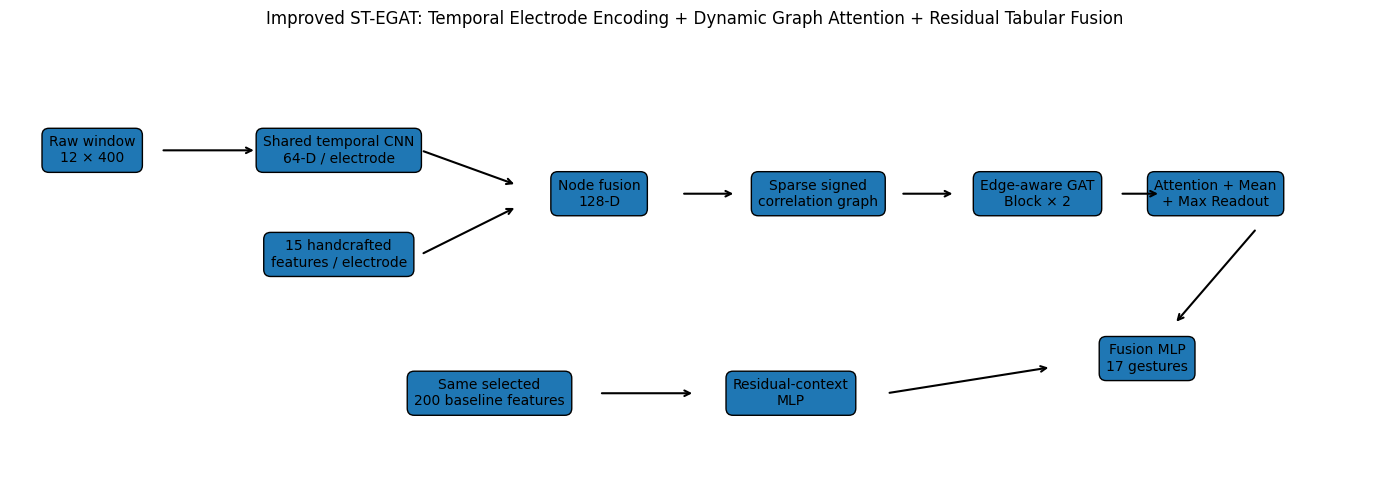

Reading: the upper path learns temporal and graph-based electrode interactions, while the lower path preserves the same strong global feature representation used for baseline comparison.


In [8]:
fig, ax = plt.subplots(
    figsize=(14, 5)
)

ax.axis("off")

boxes = [
    (0.06, 0.76, "Raw window\n12 × 400"),
    (0.24, 0.76, "Shared temporal CNN\n64-D / electrode"),
    (0.24, 0.52, "15 handcrafted\nfeatures / electrode"),
    (0.43, 0.66, "Node fusion\n128-D"),
    (0.59, 0.66, "Sparse signed\ncorrelation graph"),
    (0.75, 0.66, "Edge-aware GAT\nBlock × 2"),
    (0.88, 0.66, "Attention + Mean\n+ Max Readout"),
    (0.35, 0.20, "Same selected\n200 baseline features"),
    (0.57, 0.20, "Residual-context\nMLP"),
    (0.83, 0.28, "Fusion MLP\n17 gestures"),
]

for x, y, text in boxes:
    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        transform=ax.transAxes,
        bbox=dict(
            boxstyle="round,pad=0.5",
        ),
        fontsize=10,
    )

arrows = [
    ((0.11, 0.76), (0.18, 0.76)),
    ((0.30, 0.76), (0.37, 0.68)),
    ((0.30, 0.52), (0.37, 0.63)),
    ((0.49, 0.66), (0.53, 0.66)),
    ((0.65, 0.66), (0.69, 0.66)),
    ((0.81, 0.66), (0.84, 0.66)),
    ((0.91, 0.58), (0.85, 0.36)),
    ((0.43, 0.20), (0.50, 0.20)),
    ((0.64, 0.20), (0.76, 0.26)),
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5,
        ),
    )

ax.set_title(
    "Improved ST-EGAT: Temporal Electrode Encoding + Dynamic Graph Attention + Residual Tabular Fusion",
    pad=16,
)

plt.tight_layout()
plt.show()

print(
    "Reading: the upper path learns temporal and graph-based electrode interactions, "
    "while the lower path preserves the same strong global feature representation used for baseline comparison."
)


## 9. Improved ST-EGAT Model

In [9]:
class MultiScaleTemporalStage(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=2,
    ):
        super().__init__()

        branch_channels = max(
            12,
            out_channels // 3,
        )

        self.branch3 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )

        self.branch7 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=7,
            stride=stride,
            padding=3,
            bias=False,
        )

        self.branch15 = nn.Conv1d(
            in_channels,
            branch_channels,
            kernel_size=15,
            stride=stride,
            padding=7,
            bias=False,
        )

        merged_channels = (
            branch_channels * 3
        )

        self.merge = nn.Sequential(
            nn.BatchNorm1d(
                merged_channels
            ),
            nn.GELU(),
            nn.Conv1d(
                merged_channels,
                out_channels,
                kernel_size=1,
                bias=False,
            ),
            nn.BatchNorm1d(
                out_channels
            ),
        )

        hidden = max(
            out_channels // 4,
            8,
        )

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(
                1
            ),
            nn.Conv1d(
                out_channels,
                hidden,
                kernel_size=1,
            ),
            nn.GELU(),
            nn.Conv1d(
                hidden,
                out_channels,
                kernel_size=1,
            ),
            nn.Sigmoid(),
        )

        self.skip = nn.Sequential(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                bias=False,
            ),
            nn.BatchNorm1d(
                out_channels
            ),
        )

        self.activation = nn.GELU()

    def forward(
        self,
        x,
    ):
        residual = self.skip(
            x
        )

        x = torch.cat(
            [
                self.branch3(
                    x
                ),
                self.branch7(
                    x
                ),
                self.branch15(
                    x
                ),
            ],
            dim=1,
        )

        x = self.merge(
            x
        )

        x = (
            x
            * self.se(
                x
            )
        )

        return self.activation(
            x
            + residual
        )


class SharedTemporalEncoder(nn.Module):

    def __init__(
        self,
        output_dim=64,
    ):
        super().__init__()

        self.stage1 = MultiScaleTemporalStage(
            3,
            32,
            stride=2,
        )

        self.stage2 = MultiScaleTemporalStage(
            32,
            48,
            stride=2,
        )

        self.stage3 = MultiScaleTemporalStage(
            48,
            64,
            stride=2,
        )

        self.stage4 = MultiScaleTemporalStage(
            64,
            96,
            stride=2,
        )

        self.projection = nn.Sequential(
            nn.Linear(
                192,
                128,
            ),
            nn.LayerNorm(
                128
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                128,
                output_dim,
            ),
            nn.GELU(),
        )

    def forward(
        self,
        raw_windows,
    ):
        batch_size, num_nodes, time_steps = raw_windows.shape

        local_mean = raw_windows.mean(
            dim=-1,
            keepdim=True,
        )

        local_std = raw_windows.std(
            dim=-1,
            keepdim=True,
            unbiased=False,
        ).clamp_min(
            1e-5
        )

        local_normalized = (
            raw_windows
            - local_mean
        ) / local_std

        first_difference = torch.diff(
            raw_windows,
            dim=-1,
            prepend=raw_windows[
                :,
                :,
                :1,
            ],
        )

        x = torch.stack(
            [
                raw_windows,
                local_normalized,
                first_difference,
            ],
            dim=2,
        ).reshape(
            batch_size * num_nodes,
            3,
            time_steps,
        )

        x = self.stage1(
            x
        )

        x = self.stage2(
            x
        )

        x = self.stage3(
            x
        )

        x = self.stage4(
            x
        )

        average_pool = torch.mean(
            x,
            dim=-1,
        )

        max_pool = torch.amax(
            x,
            dim=-1,
        )

        x = torch.cat(
            [
                average_pool,
                max_pool,
            ],
            dim=1,
        )

        x = self.projection(
            x
        )

        return x.reshape(
            batch_size,
            num_nodes,
            -1,
        )


class EdgeAwareMultiHeadAttention(nn.Module):

    def __init__(
        self,
        hidden_dim=128,
        num_heads=4,
        dropout=0.10,
    ):
        super().__init__()

        assert (
            hidden_dim
            % num_heads
            == 0
        )

        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.head_dim = (
            hidden_dim
            // num_heads
        )

        self.q_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.k_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.v_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
            bias=False,
        )

        self.edge_bias = nn.Sequential(
            nn.Linear(
                2,
                32,
            ),
            nn.GELU(),
            nn.Linear(
                32,
                num_heads,
            ),
        )

        self.edge_message = nn.Sequential(
            nn.Linear(
                2,
                32,
            ),
            nn.GELU(),
            nn.Linear(
                32,
                hidden_dim,
            ),
        )

        self.log_temperature = nn.Parameter(
            torch.zeros(
                num_heads
            )
        )

        self.out_proj = nn.Linear(
            hidden_dim,
            hidden_dim,
        )

        self.attn_dropout = nn.Dropout(
            dropout
        )

        self.output_dropout = nn.Dropout(
            dropout
        )

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        batch_size, num_nodes, _ = x.shape

        q = self.q_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        k = self.k_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        v = self.v_proj(
            x
        ).view(
            batch_size,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            2,
            1,
            3,
        )

        edge_input = torch.stack(
            [
                edge_values,
                torch.abs(
                    edge_values
                ),
            ],
            dim=-1,
        )

        temperature = (
            torch.nn.functional.softplus(
                self.log_temperature
            )
            + 0.5
        ).view(
            1,
            self.num_heads,
            1,
            1,
        )

        scores = torch.matmul(
            q,
            k.transpose(
                -2,
                -1,
            ),
        ) / (
            math.sqrt(
                self.head_dim
            )
            * temperature
        )

        edge_bias = self.edge_bias(
            edge_input
        ).permute(
            0,
            3,
            1,
            2,
        )

        scores = (
            scores
            + edge_bias
        )

        scores = scores.masked_fill(
            ~edge_mask.unsqueeze(
                1
            ),
            -1e4,
        )

        attention = torch.softmax(
            scores,
            dim=-1,
        )

        attention = self.attn_dropout(
            attention
        )

        edge_message = self.edge_message(
            edge_input
        ).view(
            batch_size,
            num_nodes,
            num_nodes,
            self.num_heads,
            self.head_dim,
        ).permute(
            0,
            3,
            1,
            2,
            4,
        )

        source_values = v.unsqueeze(
            2
        ).expand(
            -1,
            -1,
            num_nodes,
            -1,
            -1,
        )

        edge_strength = (
            0.75
            + 0.50
            * torch.abs(
                edge_values
            )
        ).unsqueeze(
            1
        ).unsqueeze(
            -1
        )

        messages = (
            source_values
            + edge_message
        ) * edge_strength

        out = torch.sum(
            attention.unsqueeze(
                -1
            )
            * messages,
            dim=3,
        )

        out = out.permute(
            0,
            2,
            1,
            3,
        ).contiguous().view(
            batch_size,
            num_nodes,
            self.hidden_dim,
        )

        out = self.out_proj(
            out
        )

        return self.output_dropout(
            out
        )


class GraphAttentionBlock(nn.Module):

    def __init__(
        self,
        hidden_dim=128,
        num_heads=4,
        dropout=0.10,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(
            hidden_dim
        )

        self.attention = EdgeAwareMultiHeadAttention(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
        )

        self.attention_gate = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Sigmoid(),
        )

        self.norm2 = nn.LayerNorm(
            hidden_dim
        )

        self.ffn = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim * 3,
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim * 3,
                hidden_dim,
            ),
            nn.Dropout(
                dropout
            ),
        )

        self.ffn_gate = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Sigmoid(),
        )

    def forward(
        self,
        x,
        edge_values,
        edge_mask,
    ):
        attention_output = self.attention(
            self.norm1(
                x
            ),
            edge_values,
            edge_mask,
        )

        attention_gate = self.attention_gate(
            torch.cat(
                [
                    x,
                    attention_output,
                ],
                dim=-1,
            )
        )

        x = (
            x
            + attention_gate
            * attention_output
        )

        ffn_output = self.ffn(
            self.norm2(
                x
            )
        )

        ffn_gate = self.ffn_gate(
            torch.cat(
                [
                    x,
                    ffn_output,
                ],
                dim=-1,
            )
        )

        return (
            x
            + ffn_gate
            * ffn_output
        )


class ResidualGlobalBlock(nn.Module):

    def __init__(
        self,
        width,
        dropout=0.10,
    ):
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(
                width,
                width * 2,
            ),
            nn.BatchNorm1d(
                width * 2
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                width * 2,
                width,
            ),
            nn.BatchNorm1d(
                width
            ),
        )

        self.activation = nn.GELU()

    def forward(
        self,
        x,
    ):
        return self.activation(
            x
            + self.block(
                x
            )
        )


class ImprovedSTEGAT(nn.Module):

    def __init__(
        self,
        node_feature_dim=15,
        global_feature_dim=200,
        hidden_dim=160,
        num_heads=4,
        num_classes=17,
        dropout=0.15,
    ):
        super().__init__()

        self.temporal_encoder = SharedTemporalEncoder(
            output_dim=64
        )

        self.handcrafted_input = nn.Linear(
            node_feature_dim,
            64,
        )

        self.handcrafted_encoder = nn.Sequential(
            nn.LayerNorm(
                64
            ),
            nn.GELU(),
            nn.Linear(
                64,
                128,
            ),
            nn.GELU(),
            nn.Dropout(
                0.06
            ),
            nn.Linear(
                128,
                64,
            ),
        )

        self.node_gate = nn.Sequential(
            nn.Linear(
                128,
                64,
            ),
            nn.Sigmoid(),
        )

        self.node_fusion = nn.Sequential(
            nn.Linear(
                128,
                hidden_dim,
            ),
            nn.LayerNorm(
                hidden_dim
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
        )

        self.graph_block1 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.graph_block2 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.graph_block3 = GraphAttentionBlock(
            hidden_dim=hidden_dim,
            num_heads=num_heads,
            dropout=0.10,
        )

        self.jumping_fusion = nn.Sequential(
            nn.Linear(
                hidden_dim * 4,
                hidden_dim * 2,
            ),
            nn.LayerNorm(
                hidden_dim * 2
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
        )

        self.node_attention = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.Tanh(),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

        self.global_input = nn.Sequential(
            nn.Linear(
                global_feature_dim,
                256,
            ),
            nn.BatchNorm1d(
                256
            ),
            nn.GELU(),
        )

        self.global_residual1 = ResidualGlobalBlock(
            256,
            dropout=0.10,
        )

        self.global_residual2 = ResidualGlobalBlock(
            256,
            dropout=0.10,
        )

        self.global_output = nn.Sequential(
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                256,
                192,
            ),
            nn.BatchNorm1d(
                192
            ),
            nn.GELU(),
        )

        graph_readout_dim = (
            hidden_dim * 3
        )

        fusion_dim = (
            graph_readout_dim
            + 192
        )

        self.fusion_classifier = nn.Sequential(
            nn.Linear(
                fusion_dim,
                384,
            ),
            nn.LayerNorm(
                384
            ),
            nn.GELU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                384,
                192,
            ),
            nn.GELU(),
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                192,
                num_classes,
            ),
        )

        self.graph_classifier = nn.Sequential(
            nn.Linear(
                graph_readout_dim,
                192,
            ),
            nn.GELU(),
            nn.Dropout(
                0.10
            ),
            nn.Linear(
                192,
                num_classes,
            ),
        )

        self.global_classifier = nn.Sequential(
            nn.Linear(
                192,
                128,
            ),
            nn.GELU(),
            nn.Dropout(
                0.08
            ),
            nn.Linear(
                128,
                num_classes,
            ),
        )

        self.expert_weights = nn.Parameter(
            torch.tensor(
                [
                    1.0,
                    1.0,
                    1.0,
                ],
                dtype=torch.float32,
            )
        )

    def forward(
        self,
        raw_windows,
        node_features,
        edge_values,
        edge_mask,
        global_features,
        return_node_attention=False,
        return_expert_logits=False,
    ):
        temporal_features = self.temporal_encoder(
            raw_windows
        )

        handcrafted_base = self.handcrafted_input(
            node_features
        )

        handcrafted_features = (
            handcrafted_base
            + self.handcrafted_encoder(
                handcrafted_base
            )
        )

        gate = self.node_gate(
            torch.cat(
                [
                    temporal_features,
                    handcrafted_features,
                ],
                dim=-1,
            )
        )

        gated_temporal = (
            gate
            * temporal_features
        )

        gated_handcrafted = (
            (
                1.0
                - gate
            )
            * handcrafted_features
        )

        h0 = self.node_fusion(
            torch.cat(
                [
                    gated_temporal,
                    gated_handcrafted,
                ],
                dim=-1,
            )
        )

        h1 = self.graph_block1(
            h0,
            edge_values,
            edge_mask,
        )

        h2 = self.graph_block2(
            h1,
            edge_values,
            edge_mask,
        )

        h3 = self.graph_block3(
            h2,
            edge_values,
            edge_mask,
        )

        h = self.jumping_fusion(
            torch.cat(
                [
                    h0,
                    h1,
                    h2,
                    h3,
                ],
                dim=-1,
            )
        )

        node_scores = self.node_attention(
            h
        ).squeeze(
            -1
        )

        node_weights = torch.softmax(
            node_scores,
            dim=1,
        )

        attention_pool = torch.sum(
            h
            * node_weights.unsqueeze(
                -1
            ),
            dim=1,
        )

        mean_pool = torch.mean(
            h,
            dim=1,
        )

        max_pool = torch.max(
            h,
            dim=1,
        ).values

        graph_embedding = torch.cat(
            [
                attention_pool,
                mean_pool,
                max_pool,
            ],
            dim=1,
        )

        global_embedding = self.global_input(
            global_features
        )

        global_embedding = self.global_residual1(
            global_embedding
        )

        global_embedding = self.global_residual2(
            global_embedding
        )

        global_embedding = self.global_output(
            global_embedding
        )

        fused = torch.cat(
            [
                graph_embedding,
                global_embedding,
            ],
            dim=1,
        )

        fusion_logits = self.fusion_classifier(
            fused
        )

        graph_logits = self.graph_classifier(
            graph_embedding
        )

        global_logits = self.global_classifier(
            global_embedding
        )

        expert_weights = torch.softmax(
            self.expert_weights,
            dim=0,
        )

        logits = (
            expert_weights[
                0
            ]
            * fusion_logits
            + expert_weights[
                1
            ]
            * graph_logits
            + expert_weights[
                2
            ]
            * global_logits
        )

        if return_expert_logits:
            return (
                logits,
                graph_logits,
                global_logits,
            )

        if return_node_attention:
            return (
                logits,
                node_weights,
            )

        return logits


gnn_model = ImprovedSTEGAT(
    node_feature_dim=N_NODE_FEATURES,
    global_feature_dim=X_train_global.shape[1],
    hidden_dim=160,
    num_heads=4,
    num_classes=N_CLASSES,
    dropout=0.15,
).to(
    DEVICE
)

with torch.no_grad():
    (
        check_logits,
        check_node_weights,
    ) = gnn_model(
        sample_raw[:8].to(
            DEVICE
        ),
        sample_nodes[:8].to(
            DEVICE
        ),
        sample_edges[:8].to(
            DEVICE
        ),
        sample_mask[:8].to(
            DEVICE
        ),
        sample_global[:8].to(
            DEVICE
        ),
        return_node_attention=True,
    )

total_parameters = sum(
    parameter.numel()
    for parameter in gnn_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in gnn_model.parameters()
    if parameter.requires_grad
)

print("Model               : ImprovedSTEGAT")
print("Output logits       :", check_logits.shape)
print("Node-attention shape:", check_node_weights.shape)
print(
    "Attention sum       :",
    float(
        check_node_weights[
            0
        ].sum()
    ),
)
print(
    "Expert weights      :",
    torch.softmax(
        gnn_model.expert_weights.detach(),
        dim=0,
    ).cpu().numpy(),
)
print(
    "Total parameters    :",
    f"{total_parameters:,}",
)
print(
    "Trainable parameters:",
    f"{trainable_parameters:,}",
)
print(
    "Device              :",
    next(
        gnn_model.parameters()
    ).device,
)

assert check_logits.shape == (
    8,
    N_CLASSES,
)

assert check_node_weights.shape == (
    8,
    N_CHANNELS,
)

assert torch.allclose(
    check_node_weights.sum(
        dim=1
    ),
    torch.ones(
        8,
        device=DEVICE,
    ),
    atol=1e-5,
)

assert torch.isfinite(
    check_logits
).all()

print(
    "\nImproved ST-EGAT forward-pass check: PASSED"
)


Model               : ImprovedSTEGAT
Output logits       : torch.Size([8, 17])
Node-attention shape: torch.Size([8, 12])
Attention sum       : 0.9999999403953552
Expert weights      : [0.33333334 0.33333334 0.33333334]
Total parameters    : 2,677,749
Trainable parameters: 2,677,749
Device              : cuda:0

Improved ST-EGAT forward-pass check: PASSED


## 10. Fixed-Epoch Training — Same Comparison Protocol

In [10]:
EPOCHS = 55
LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 3e-4
AUX_LOSS_WEIGHT = 0.3

loss_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)

criterion = nn.CrossEntropyLoss(
    weight=loss_weights,
    label_smoothing=0.02,
)

optimizer = torch.optim.AdamW(
    gnn_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=EPOCHS,
    steps_per_epoch=len(
        train_loader
    ),
    pct_start=0.18,
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=100.0,
)

USE_AMP = (
    DEVICE.type == "cuda"
)

amp_scaler = torch.cuda.amp.GradScaler(
    enabled=USE_AMP
)

EMA_DECAY = 0.98
EMA_START_EPOCH = 8
EMA_UPDATE_EVERY = 4

ema_state = {
    key: value.detach().clone()
    for key, value
    in gnn_model.state_dict().items()
}

history = []

training_start = time.perf_counter()

print("Improved ST-EGAT training")
print("-------------------------")
print("Device :", DEVICE)
print("Epochs :", EPOCHS)
print("AMP    :", USE_AMP)

global_step = 0

for epoch in range(
    1,
    EPOCHS + 1,
):
    gnn_model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    epoch_start = time.perf_counter()

    for (
        raw_x,
        node_x,
        edge_values,
        edge_mask,
        global_x,
        labels,
    ) in train_loader:

        raw_x = raw_x.to(
            DEVICE,
            non_blocking=True,
        )

        node_x = node_x.to(
            DEVICE,
            non_blocking=True,
        )

        edge_values = edge_values.to(
            DEVICE,
            non_blocking=True,
        )

        edge_mask = edge_mask.to(
            DEVICE,
            non_blocking=True,
        )

        global_x = global_x.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )

        if epoch <= 44:
            amplitude_scale = (
                0.92
                + 0.16
                * torch.rand(
                    raw_x.shape[
                        0
                    ],
                    raw_x.shape[
                        1
                    ],
                    1,
                    device=DEVICE,
                )
            )

            raw_x = (
                raw_x
                * amplitude_scale
            )

            raw_x = (
                raw_x
                + 0.012
                * torch.randn_like(
                    raw_x
                )
            )

            if (
                epoch <= 31
                and random.random()
                < 0.35
            ):
                mask_width = random.randint(
                    6,
                    18,
                )

                mask_start = random.randint(
                    0,
                    WINDOW_SIZE
                    - mask_width,
                )

                raw_x[
                    :,
                    :,
                    mask_start:
                    mask_start
                    + mask_width
                ] = 0.0

            node_x = torch.nn.functional.dropout(
                node_x,
                p=0.025,
                training=True,
            )

            global_x = torch.nn.functional.dropout(
                global_x,
                p=0.02,
                training=True,
            )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.cuda.amp.autocast(
            enabled=USE_AMP
        ):
            (
                logits,
                aux_graph_logits,
                aux_global_logits,
            ) = gnn_model(
                raw_x,
                node_x,
                edge_values,
                edge_mask,
                global_x,
                return_expert_logits=True,
            )

            loss = (
                criterion(
                    logits,
                    labels,
                )
                + AUX_LOSS_WEIGHT
                * criterion(
                    aux_graph_logits,
                    labels,
                )
                + AUX_LOSS_WEIGHT
                * criterion(
                    aux_global_logits,
                    labels,
                )
            )

        amp_scaler.scale(
            loss
        ).backward()

        amp_scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            gnn_model.parameters(),
            max_norm=3.0,
        )

        amp_scaler.step(
            optimizer
        )

        amp_scaler.update()

        scheduler.step()

        global_step += 1

        if (
            epoch >= EMA_START_EPOCH
            and global_step
            % EMA_UPDATE_EVERY
            == 0
        ):
            current_state = gnn_model.state_dict()

            with torch.no_grad():
                for key in ema_state:
                    current_value = current_state[
                        key
                    ]

                    if torch.is_floating_point(
                        current_value
                    ):
                        ema_state[
                            key
                        ].mul_(
                            EMA_DECAY
                        ).add_(
                            current_value.detach(),
                            alpha=(
                                1.0
                                - EMA_DECAY
                            ),
                        )

                    else:
                        ema_state[
                            key
                        ].copy_(
                            current_value
                        )

        running_loss += (
            loss.item()
            * len(labels)
        )

        predictions = torch.argmax(
            logits.detach(),
            dim=1,
        )

        running_correct += int(
            (
                predictions
                == labels
            )
            .sum()
            .item()
        )

        running_total += len(
            labels
        )

    train_loss = (
        running_loss
        / running_total
    )

    train_accuracy = (
        running_correct
        / running_total
    )

    epoch_time = (
        time.perf_counter()
        - epoch_start
    )

    current_lr = optimizer.param_groups[
        0
    ]["lr"]

    history.append(
        {
            "Epoch": epoch,
            "Train Loss": train_loss,
            "Train Accuracy": train_accuracy,
            "Learning Rate": current_lr,
            "Epoch Time (s)": epoch_time,
        }
    )

    if (
        epoch == 1
        or epoch % 5 == 0
        or epoch == EPOCHS
    ):
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"loss: {train_loss:.4f} | "
            f"train acc: {train_accuracy:.4f} | "
            f"lr: {current_lr:.6f} | "
            f"time: {epoch_time:.1f}s"
        )


gnn_model.load_state_dict(
    ema_state
)

gnn_training_time = (
    time.perf_counter()
    - training_start
)

print(
    "\nTotal training time:",
    f"{gnn_training_time:.2f}s",
)

print(
    "Final expert weights:",
    torch.softmax(
        gnn_model.expert_weights.detach(),
        dim=0,
    ).cpu().numpy(),
)

assert np.isfinite(
    history[-1][
        "Train Loss"
    ]
)

print(
    "Fixed-epoch improved GNN training: PASSED"
)


Improved ST-EGAT training
-------------------------
Device : cuda:0
Epochs : 55
AMP    : True
Epoch 01/55 | loss: 3.6959 | train acc: 0.2904 | lr: 0.000122 | time: 73.9s
Epoch 05/55 | loss: 1.9792 | train acc: 0.6756 | lr: 0.000557 | time: 62.7s
Epoch 10/55 | loss: 1.2886 | train acc: 0.8188 | lr: 0.001000 | time: 63.3s
Epoch 15/55 | loss: 0.9019 | train acc: 0.9010 | lr: 0.000969 | time: 63.5s
Epoch 20/55 | loss: 0.7007 | train acc: 0.9415 | lr: 0.000881 | time: 63.6s
Epoch 25/55 | loss: 0.5720 | train acc: 0.9659 | lr: 0.000748 | time: 63.4s
Epoch 30/55 | loss: 0.4783 | train acc: 0.9804 | lr: 0.000585 | time: 63.5s
Epoch 35/55 | loss: 0.4054 | train acc: 0.9901 | lr: 0.000412 | time: 63.5s
Epoch 40/55 | loss: 0.3578 | train acc: 0.9955 | lr: 0.000250 | time: 63.5s
Epoch 45/55 | loss: 0.3106 | train acc: 0.9991 | lr: 0.000117 | time: 63.5s
Epoch 50/55 | loss: 0.2982 | train acc: 0.9996 | lr: 0.000031 | time: 63.4s
Epoch 55/55 | loss: 0.2959 | train acc: 0.9997 | lr: 0.000001 | time: 

## 11. Training Curves

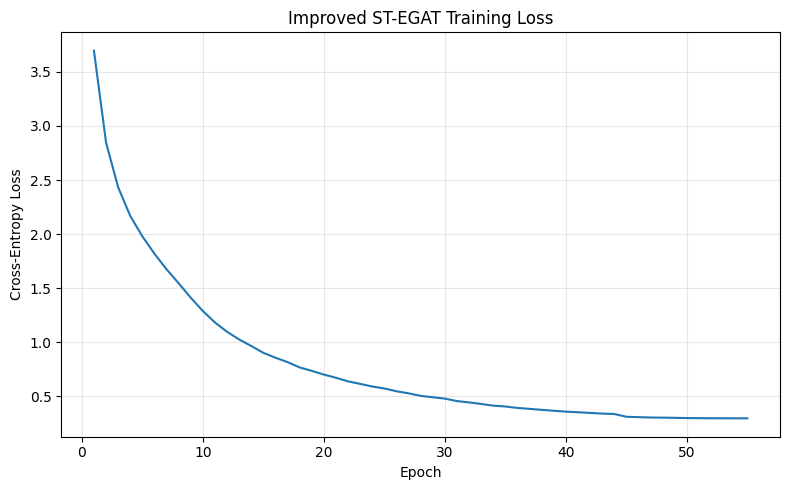

Reading: a steadily decreasing training loss indicates that the optimizer is learning a stable decision function from the training repetitions.


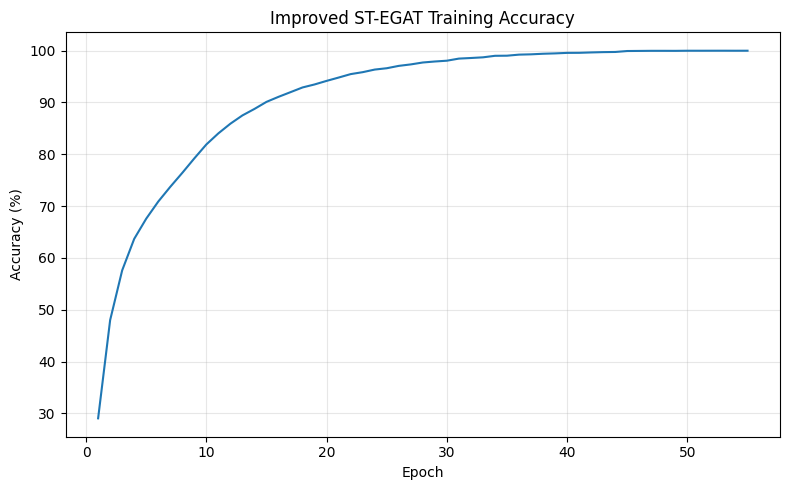

Reading: training accuracy shows how well the model fits repetitions 1, 3, 4, and 6; the final test result below is computed once on repetitions 2 and 5 after training.


In [11]:
history_df = pd.DataFrame(
    history
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    history_df[
        "Epoch"
    ],
    history_df[
        "Train Loss"
    ],
)

ax.set_title(
    "Improved ST-EGAT Training Loss"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Cross-Entropy Loss"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

print(
    "Reading: a steadily decreasing training loss indicates that the "
    "optimizer is learning a stable decision function from the training repetitions."
)


fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    history_df[
        "Epoch"
    ],
    history_df[
        "Train Accuracy"
    ] * 100,
)

ax.set_title(
    "Improved ST-EGAT Training Accuracy"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Accuracy (%)"
)

ax.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

print(
    "Reading: training accuracy shows how well the model fits repetitions "
    "1, 3, 4, and 6; the final test result below is computed once on repetitions 2 and 5 after training."
)


## 12. Final First Result on Test Repetitions 2 and 5

In [12]:
gnn_model.eval()

all_true = []
all_pred = []
all_proba = []
all_node_attention = []

inference_start = time.perf_counter()

with torch.no_grad():

    for (
        raw_x,
        node_x,
        edge_values,
        edge_mask,
        global_x,
        labels,
    ) in test_loader:

        raw_x = raw_x.to(
            DEVICE,
            non_blocking=True,
        )

        node_x = node_x.to(
            DEVICE,
            non_blocking=True,
        )

        edge_values = edge_values.to(
            DEVICE,
            non_blocking=True,
        )

        edge_mask = edge_mask.to(
            DEVICE,
            non_blocking=True,
        )

        global_x = global_x.to(
            DEVICE,
            non_blocking=True,
        )

        with torch.cuda.amp.autocast(
            enabled=USE_AMP
        ):
            (
                logits,
                node_attention,
            ) = gnn_model(
                raw_x,
                node_x,
                edge_values,
                edge_mask,
                global_x,
                return_node_attention=True,
            )

        probabilities = torch.softmax(
            logits.float(),
            dim=1,
        )

        predictions = torch.argmax(
            probabilities,
            dim=1,
        )

        all_true.append(
            labels.numpy()
        )

        all_pred.append(
            predictions.cpu().numpy()
        )

        all_proba.append(
            probabilities.cpu().numpy()
        )

        all_node_attention.append(
            node_attention.cpu().numpy()
        )


gnn_inference_time = (
    time.perf_counter()
    - inference_start
)

gnn_true = np.concatenate(
    all_true
)

gnn_pred = np.concatenate(
    all_pred
)

gnn_proba = np.vstack(
    all_proba
)

gnn_node_attention = np.vstack(
    all_node_attention
)

gnn_true_binary = label_binarize(
    gnn_true,
    classes=np.arange(N_CLASSES),
)

gnn_results = {
    "Accuracy": accuracy_score(
        gnn_true,
        gnn_pred,
    ),
    "Macro Precision": precision_score(
        gnn_true,
        gnn_pred,
        average="macro",
        zero_division=0,
    ),
    "Macro Recall": recall_score(
        gnn_true,
        gnn_pred,
        average="macro",
        zero_division=0,
    ),
    "Macro F1": f1_score(
        gnn_true,
        gnn_pred,
        average="macro",
        zero_division=0,
    ),
    "Weighted Precision": precision_score(
        gnn_true,
        gnn_pred,
        average="weighted",
        zero_division=0,
    ),
    "Weighted Recall": recall_score(
        gnn_true,
        gnn_pred,
        average="weighted",
        zero_division=0,
    ),
    "Weighted F1": f1_score(
        gnn_true,
        gnn_pred,
        average="weighted",
        zero_division=0,
    ),
    "ROC-AUC Macro": roc_auc_score(
        gnn_true_binary,
        gnn_proba,
        average="macro",
        multi_class="ovr",
    ),
    "PR-AUC Macro": average_precision_score(
        gnn_true_binary,
        gnn_proba,
        average="macro",
    ),
    "Training Time (s)": gnn_training_time,
    "Inference Time (s)": gnn_inference_time,
}

print("Improved ST-EGAT — Test Results")
print("-------------------------------")

for metric, value in gnn_results.items():

    if "Time" in metric:
        print(
            f"{metric:22s}: {value:.2f}"
        )

    else:
        print(
            f"{metric:22s}: "
            f"{value:.4f} "
            f"({value * 100:.2f}%)"
        )


macro_f1_change = (
    gnn_results[
        "Macro F1"
    ]
    - BASELINE_MACRO_F1
) * 100

accuracy_change = (
    gnn_results[
        "Accuracy"
    ]
    - BASELINE_ACCURACY
) * 100

print("\nComparison with best baseline")
print("-----------------------------")
print(
    "XGBoost Accuracy :",
    f"{BASELINE_ACCURACY * 100:.2f}%"
)
print(
    "GNN Accuracy     :",
    f"{gnn_results['Accuracy'] * 100:.2f}%"
)
print(
    "Accuracy change  :",
    f"{accuracy_change:+.2f} percentage points"
)

print(
    "XGBoost Macro-F1 :",
    f"{BASELINE_MACRO_F1 * 100:.2f}%"
)
print(
    "GNN Macro-F1     :",
    f"{gnn_results['Macro F1'] * 100:.2f}%"
)
print(
    "Macro-F1 change  :",
    f"{macro_f1_change:+.2f} percentage points"
)

if macro_f1_change > 0:
    print(
        "\nReading: the improved proposed GNN beats the strongest baseline on Macro-F1 "
        f"by {macro_f1_change:.2f} percentage points under the same repetition split."
    )
else:
    print(
        "\nReading: the improved proposed GNN remains below the strongest baseline on Macro-F1 "
        f"by {abs(macro_f1_change):.2f} percentage points. "
        "This is still the Task 2 first-result comparison and later systematic tuning belongs in Task 3."
    )

assert len(gnn_true) == len(
    test_dataset
)

assert gnn_proba.shape == (
    len(test_dataset),
    N_CLASSES,
)

assert np.isfinite(
    gnn_proba
).all()

assert np.allclose(
    gnn_proba.sum(
        axis=1
    ),
    1.0,
    atol=1e-4,
)

print("\nFinal improved GNN evaluation: PASSED")


Improved ST-EGAT — Test Results
-------------------------------
Accuracy              : 0.8116 (81.16%)
Macro Precision       : 0.8109 (81.09%)
Macro Recall          : 0.8092 (80.92%)
Macro F1              : 0.8098 (80.98%)
Weighted Precision    : 0.8117 (81.17%)
Weighted Recall       : 0.8116 (81.16%)
Weighted F1           : 0.8114 (81.14%)
ROC-AUC Macro         : 0.9766 (97.66%)
PR-AUC Macro          : 0.8693 (86.93%)
Training Time (s)     : 3495.64
Inference Time (s)    : 10.17

Comparison with best baseline
-----------------------------
XGBoost Accuracy : 77.69%
GNN Accuracy     : 81.16%
Accuracy change  : +3.46 percentage points
XGBoost Macro-F1 : 77.39%
GNN Macro-F1     : 80.98%
Macro-F1 change  : +3.59 percentage points

Reading: the improved proposed GNN beats the strongest baseline on Macro-F1 by 3.59 percentage points under the same repetition split.

Final improved GNN evaluation: PASSED


## 13. Direct XGBoost Baseline vs. Improved Proposed GNN Comparison

In [13]:
comparison = pd.DataFrame(
    [
        {
            "Model": "XGBoost Baseline",
            "Accuracy": BASELINE_ACCURACY,
            "Macro F1": BASELINE_MACRO_F1,
            "ROC-AUC Macro": BASELINE_ROC_AUC,
            "PR-AUC Macro": BASELINE_PR_AUC,
            "Training Time (s)": BASELINE_TRAINING_TIME,
        },
        {
            "Model": "Improved ST-EGAT",
            "Accuracy": gnn_results[
                "Accuracy"
            ],
            "Macro F1": gnn_results[
                "Macro F1"
            ],
            "ROC-AUC Macro": gnn_results[
                "ROC-AUC Macro"
            ],
            "PR-AUC Macro": gnn_results[
                "PR-AUC Macro"
            ],
            "Training Time (s)": gnn_results[
                "Training Time (s)"
            ],
        },
    ]
)

comparison_display = comparison.copy()

for column in [
    "Accuracy",
    "Macro F1",
    "ROC-AUC Macro",
    "PR-AUC Macro",
]:
    comparison_display[
        column
    ] = (
        comparison_display[
            column
        ] * 100
    )

display(
    comparison_display.style.format(
        {
            "Accuracy": "{:.2f}%",
            "Macro F1": "{:.2f}%",
            "ROC-AUC Macro": "{:.2f}%",
            "PR-AUC Macro": "{:.2f}%",
            "Training Time (s)": "{:.2f}",
        }
    )
)

winner = comparison.loc[
    comparison[
        "Macro F1"
    ].idxmax(),
    "Model",
]

print(
    "Reading: Macro-F1 is the primary ranking metric. "
    f"Under this common protocol, {winner} has the higher Macro-F1."
)


,Model,Accuracy,Macro F1,ROC-AUC Macro,PR-AUC Macro,Training Time (s)
0,XGBoost Baseline,77.69%,77.39%,98.25%,85.99%,304.19
1,Improved ST-EGAT,81.16%,80.98%,97.66%,86.93%,3495.64


Reading: Macro-F1 is the primary ranking metric. Under this common protocol, Improved ST-EGAT has the higher Macro-F1.


## 14. Improved GNN — Per-Class Precision, Recall, F1, and Confusion Matrix

,Gesture,Precision,Recall,F1-score,Support
0,1,0.891,0.917,0.904,"4,722"
1,2,0.790,0.854,0.820,"4,070"
2,3,0.851,0.798,0.824,"3,691"
3,4,0.788,0.802,0.795,"3,522"
4,5,0.765,0.768,0.767,"3,639"
5,6,0.854,0.841,0.847,"2,967"
6,7,0.844,0.852,0.848,"4,519"
7,8,0.775,0.782,0.779,"3,431"
8,9,0.772,0.784,0.778,"3,702"
9,10,0.825,0.789,0.807,"3,809"


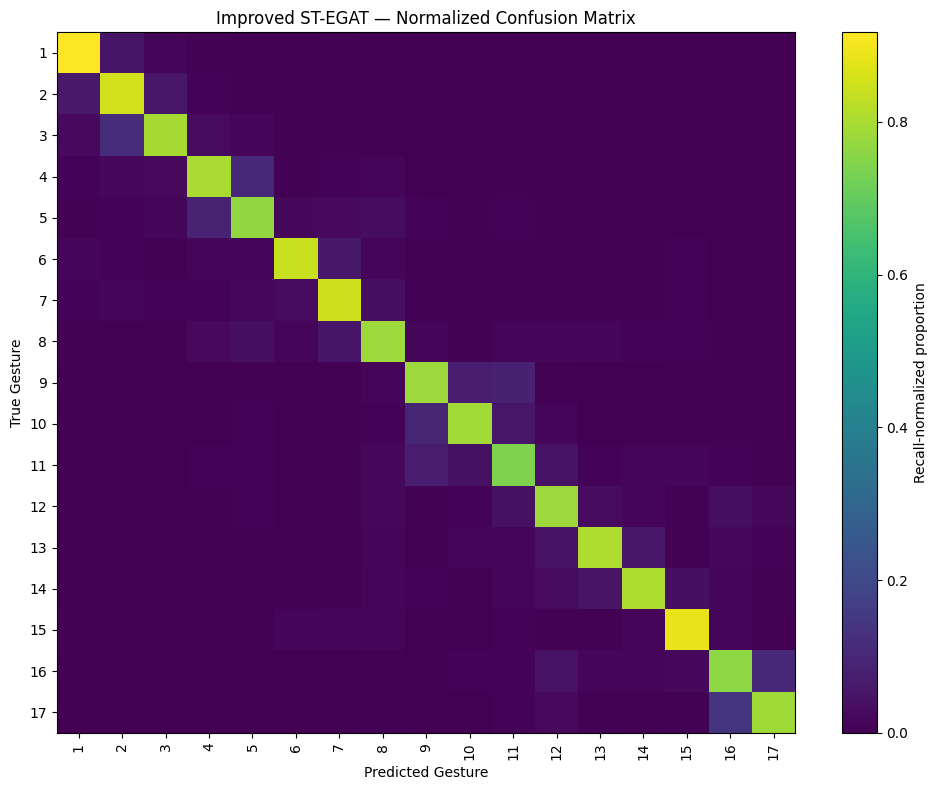

Reading: the diagonal represents correct classifications. Gesture 1 has the highest recall, while gesture 11 has the lowest recall and is the clearest target for later improvement.


In [14]:
(
    class_precision,
    class_recall,
    class_f1,
    class_support,
) = precision_recall_fscore_support(
    gnn_true,
    gnn_pred,
    labels=np.arange(N_CLASSES),
    zero_division=0,
)

per_class_df = pd.DataFrame(
    {
        "Gesture": np.arange(
            1,
            N_CLASSES + 1,
        ),
        "Precision": class_precision,
        "Recall": class_recall,
        "F1-score": class_f1,
        "Support": class_support,
    }
)

display(
    per_class_df.style.format(
        {
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1-score": "{:.3f}",
            "Support": "{:,}",
        }
    )
)

cm = confusion_matrix(
    gnn_true,
    gnn_pred,
    labels=np.arange(N_CLASSES),
    normalize="true",
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    cm,
    aspect="auto",
)

ax.set_title(
    "Improved ST-EGAT — Normalized Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Gesture"
)

ax.set_ylabel(
    "True Gesture"
)

ticks = np.arange(
    N_CLASSES
)

ax.set_xticks(
    ticks
)

ax.set_yticks(
    ticks
)

ax.set_xticklabels(
    np.arange(
        1,
        N_CLASSES + 1,
    ),
    rotation=90,
)

ax.set_yticklabels(
    np.arange(
        1,
        N_CLASSES + 1,
    )
)

colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label(
    "Recall-normalized proportion"
)

plt.tight_layout()
plt.show()

best_gesture = int(
    per_class_df.loc[
        per_class_df[
            "Recall"
        ].idxmax(),
        "Gesture",
    ]
)

weakest_gesture = int(
    per_class_df.loc[
        per_class_df[
            "Recall"
        ].idxmin(),
        "Gesture",
    ]
)

print(
    "Reading: the diagonal represents correct classifications. "
    f"Gesture {best_gesture} has the highest recall, while gesture "
    f"{weakest_gesture} has the lowest recall and is the clearest target for later improvement."
)


## 15. Improved GNN — One-vs-Rest ROC Curves with AUC

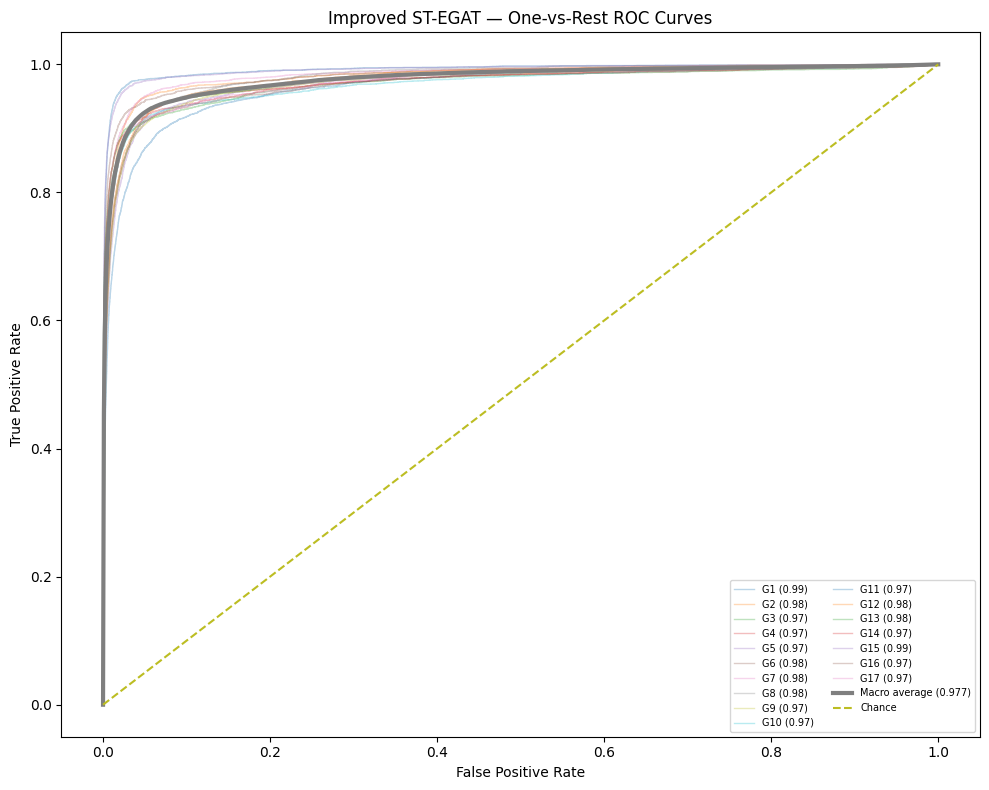

Reading: curves closer to the top-left indicate stronger class separation. The macro ROC-AUC is 0.977.


In [15]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

fpr_grid = np.linspace(
    0.0,
    1.0,
    1000,
)

class_tprs = []

for class_id in range(
    N_CLASSES
):
    fpr, tpr, _ = roc_curve(
        gnn_true_binary[
            :,
            class_id
        ],
        gnn_proba[
            :,
            class_id
        ],
    )

    class_auc = np.trapz(
        tpr,
        fpr,
    )

    ax.plot(
        fpr,
        tpr,
        alpha=0.30,
        linewidth=1,
        label=(
            f"G{class_id + 1} "
            f"({class_auc:.2f})"
        ),
    )

    interpolated = np.interp(
        fpr_grid,
        fpr,
        tpr,
    )

    interpolated[
        0
    ] = 0.0

    class_tprs.append(
        interpolated
    )

macro_tpr = np.mean(
    class_tprs,
    axis=0,
)

macro_tpr[
    -1
] = 1.0

ax.plot(
    fpr_grid,
    macro_tpr,
    linewidth=3,
    label=(
        "Macro average "
        f"({gnn_results['ROC-AUC Macro']:.3f})"
    ),
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance",
)

ax.set_title(
    "Improved ST-EGAT — One-vs-Rest ROC Curves"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend(
    loc="lower right",
    fontsize=7,
    ncol=2,
)

plt.tight_layout()
plt.show()

print(
    "Reading: curves closer to the top-left indicate stronger class separation. "
    f"The macro ROC-AUC is {gnn_results['ROC-AUC Macro']:.3f}."
)


## 16. Improved GNN — One-vs-Rest Precision–Recall Curves

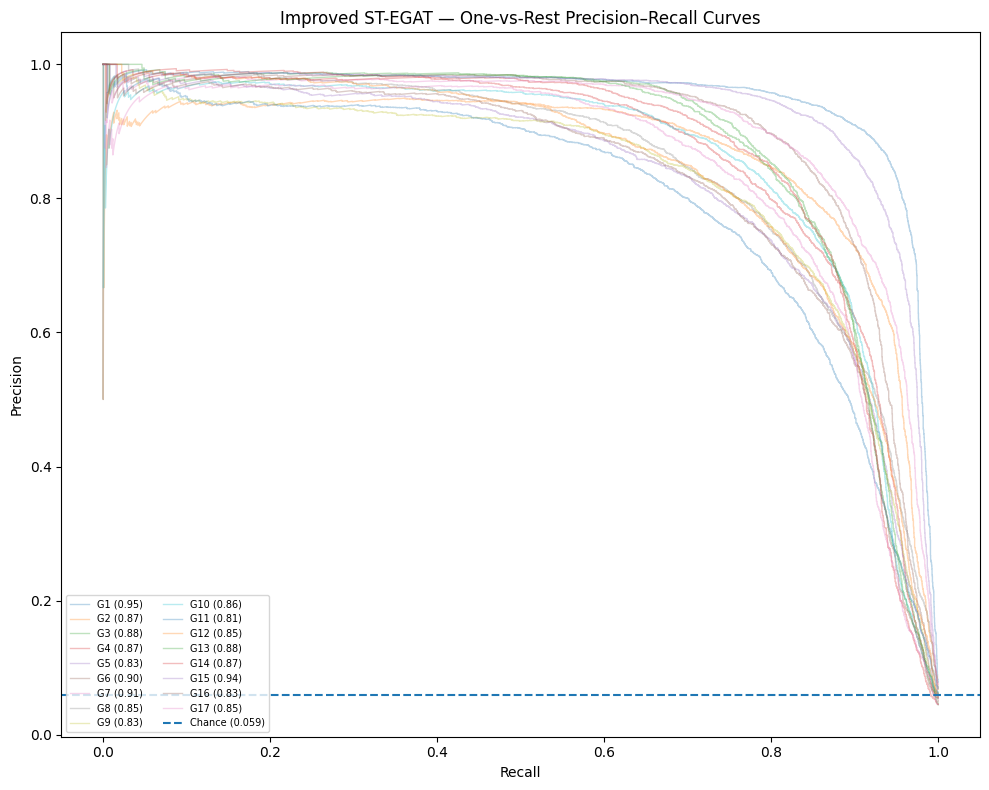

Reading: higher precision across a broad recall range is better. The macro PR-AUC is 0.869.


In [16]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

for class_id in range(
    N_CLASSES
):
    precision, recall, _ = precision_recall_curve(
        gnn_true_binary[
            :,
            class_id
        ],
        gnn_proba[
            :,
            class_id
        ],
    )

    class_ap = average_precision_score(
        gnn_true_binary[
            :,
            class_id
        ],
        gnn_proba[
            :,
            class_id
        ],
    )

    ax.plot(
        recall,
        precision,
        alpha=0.30,
        linewidth=1,
        label=(
            f"G{class_id + 1} "
            f"({class_ap:.2f})"
        ),
    )

chance_level = (
    1.0 / N_CLASSES
)

ax.axhline(
    chance_level,
    linestyle="--",
    label=(
        f"Chance ({chance_level:.3f})"
    ),
)

ax.set_title(
    "Improved ST-EGAT — One-vs-Rest Precision–Recall Curves"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.legend(
    loc="lower left",
    fontsize=7,
    ncol=2,
)

plt.tight_layout()
plt.show()

print(
    "Reading: higher precision across a broad recall range is better. "
    f"The macro PR-AUC is {gnn_results['PR-AUC Macro']:.3f}."
)


## 17. Learned Electrode Importance


,Electrode,Mean Attention
0,Ch12,0.1958
1,Ch1,0.1155
2,Ch11,0.0982
3,Ch10,0.0806
4,Ch9,0.0791
5,Ch5,0.0764
6,Ch6,0.0692
7,Ch8,0.0658
8,Ch2,0.0629
9,Ch4,0.0585


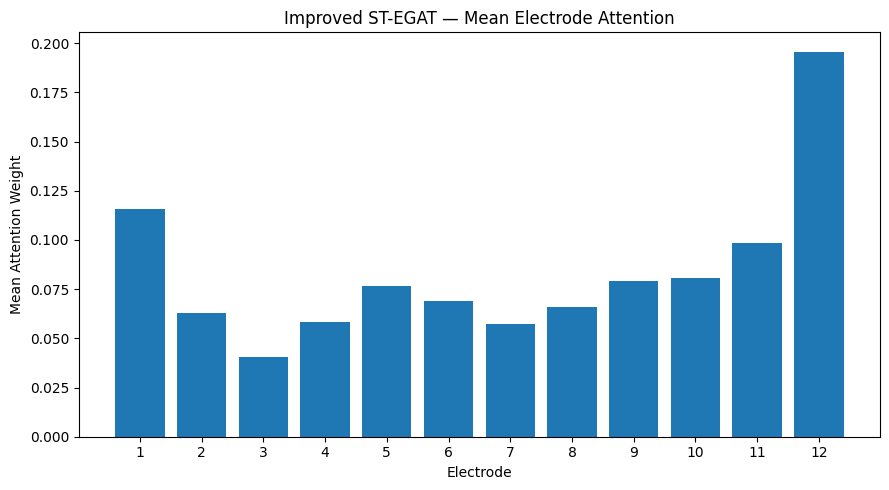

Reading: electrode 12 receives the highest average readout attention. The distribution shows which electrode representations the trained model relies on most at graph readout.


In [17]:
mean_electrode_attention = np.mean(
    gnn_node_attention,
    axis=0,
)

attention_df = pd.DataFrame(
    {
        "Electrode": [
            f"Ch{i}"
            for i in range(
                1,
                N_CHANNELS + 1,
            )
        ],
        "Mean Attention": mean_electrode_attention,
    }
).sort_values(
    "Mean Attention",
    ascending=False,
).reset_index(
    drop=True
)

display(
    attention_df.style.format(
        {
            "Mean Attention": "{:.4f}",
        }
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    np.arange(
        1,
        N_CHANNELS + 1,
    ),
    mean_electrode_attention,
)

ax.set_title(
    "Improved ST-EGAT — Mean Electrode Attention"
)

ax.set_xlabel(
    "Electrode"
)

ax.set_ylabel(
    "Mean Attention Weight"
)

ax.set_xticks(
    np.arange(
        1,
        N_CHANNELS + 1,
    )
)

plt.tight_layout()
plt.show()

top_electrode = int(
    np.argmax(
        mean_electrode_attention
    )
    + 1
)

print(
    "Reading: electrode "
    f"{top_electrode} receives the highest average readout attention. "
    "The distribution shows which electrode representations the trained model relies on most at graph readout."
)
